

---


# Práctica 1: ESTADÍSTICA DESCRIPTIVA.


---



# Antes de empezar 🛑

 * Crear una cuenta de gmail [(enlace)](https://accounts.google.com/signup/v2/webcreateaccount?flowName=GlifWebSignIn&flowEntry=SignUp).




##   Importamos librerías 📖



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model


# Estadística Descriptiva 📋

## Cargamos los datos ⬇

In [2]:
jjoo = pd.read_csv('https://raw.githubusercontent.com/asuncionjc/Datasets_lectures/main/jjoo_abreviado.csv', sep =';') #Fuente: https://www.kaggle.com/datasets/mysarahmadbhat/120-years-of-olympic-history
penaltis = pd.read_csv('https://raw.githubusercontent.com/asuncionjc/Datasets_lectures/main/penaltis.csv', sep = ';') # Especial agradecimiento para @LaLigaEnDirecto (https://twitter.com/LaLigaenDirecto)
portatiles = pd.read_csv('https://raw.githubusercontent.com/asuncionjc/Datasets_lectures/main/portatiles.csv', sep = ';') #Fuente: https://www.kaggle.com/datasets/dhananjay28kumar/laptop-price
malaga = pd.read_csv('https://raw.githubusercontent.com/asuncionjc/Datasets_lectures/main/vuelos_Malaga.csv', sep = ';') #Fuente: https://www.flightradar24.com
vuelos = pd.read_csv('https://raw.githubusercontent.com/asuncionjc/Datasets_lectures/main/vuelos_aeropuerto.csv', sep = ';') #Fuente: https://www.flightradar24.com


## Observación de los datos 👀

In [3]:
jjoo #Variables cuantitativas continuas como el peso (weight) y la altura (height). Variables cualitativas como la estación (Season) ó el deporte (Sport)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1803,998,ke Ronnie Adolfsson,M,27.0,180.0,77.0,Sweden,SWE,1984 Winter,1984,Winter,Sarajevo,Biathlon,Biathlon Men's 20 kilometres,NaN
1804,998,ke Ronnie Adolfsson,M,27.0,180.0,77.0,Sweden,SWE,1984 Winter,1984,Winter,Sarajevo,Biathlon,Biathlon Men's 4 x 7.5 kilometres Relay,NaN
1805,999,Sune Roland Adolfsson,M,25.0,180.0,74.0,Sweden,SWE,1976 Winter,1976,Winter,Innsbruck,Biathlon,Biathlon Men's 20 kilometres,NaN
1806,999,Sune Roland Adolfsson,M,25.0,180.0,74.0,Sweden,SWE,1976 Winter,1976,Winter,Innsbruck,Biathlon,Biathlon Men's 4 x 7.5 kilometres Relay,NaN


In [4]:
penaltis #Muchas variables cualitativas de la forma Sí/No (por ejemplo 'Pie'). Se suelen codificar como 1/0.

,Número,Competición,Jornada,Día,Mes,Año,Equipo,Jugador que lo provoca,Jugador que lanza,Pie,...,Para/No Para,Jugador que lo comete,Lugar,Árbitro,Acierta/Falla,Altura,Dirección,Otros,VAR,RATIFICA VAR
0,1,Liga,1,13,Septiembre,2020,Villarreal,Gerard Moreno,Gerard Moreno,Izquierdo,...,No Para,Pablo Maffeo,El Madrigal,Estrada Fernández,Acierta,Bajo,Derecha,NaN,SÍ,NaN
1,2,Liga,2,20,Septiembre,2020,Betis,Álex Moreno,Nabil Fekir,Izquierdo,...,No Para,Óscar Plano,Benito Villamarín,Jaime Latre,Acierta,Medio,Derecha,NaN,SÍ,NaN
2,3,Liga,3,26,Septiembre,2020,Real Sociedad,Adnan Januzaj,Adnan Januzaj,Izquierdo,...,No Para,Luismi Sánchez,Martínez Valero,Díaz de Mera Escuderos,Acierta,Medio,Derecha,NaN,NaN,NaN
3,4,Liga,3,26,Septiembre,2020,Madrid,Borja Mayoral,Sergio Ramos,Derecho,...,No Para,Marc Bartra,Benito Villamarín,De Burgos Bengoetxea,Acierta,Alto,Centro,Panenka,SÍ,NaN
4,5,Liga,3,27,Septiembre,2020,Levante,José Luis Morales,Roger Martí,Derecho,...,Para,Raúl Navas,El Sadar,Melero López,Acierta,Bajo,Derecha,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,137,Liga,37,16,Mayo,2021,Cádiz,Iván Alejo,José Mari Martín Bejarano,Derecho,...,No Para,Gonzalo Verdú,Carranza,Soto Grado,Acierta,Bajo,Derecha,NaN,SÍ,NaN
137,138,Liga,37,16,Mayo,2021,Real Sociedad,Alexander Isak,Adnan Januzaj,Izquierdo,...,No Para,Lucas Olaza,Anoeta,Del Cerro Grande,Acierta,Medio,Izquierda,NaN,NaN,NaN
138,139,Liga,37,16,Mayo,2021,Betis,Borja Iglesias,Borja Iglesias,Derecho,...,No Para,Gastón Silva,Benito Villamarín,González Fuertes,Acierta,Bajo,Izquierda,NaN,NaN,NaN
139,140,Liga,38,22,Mayo,2021,Celta,Santi Mina,Iago Aspas,Izquierdo,...,No Para,Marc Bartra,Balaídos,Gil Manzano,Acierta,Bajo,Derecha,NaN,NaN,NaN


In [5]:
# Podemos ver también sólo los primeros datos
portatiles.head(4)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45


In [6]:
#o los últimos datos

malaga.tail(10)

,DateTime,Scheduled flights,Tracked flights
20,10/03/2022,122,117
21,11/03/2022,159,149
22,12/03/2022,148,140
23,13/03/2022,174,166
24,14/03/2022,140,131
25,15/03/2022,116,109
26,16/03/2022,118,110
27,17/03/2022,115,110
28,18/03/2022,164,155
29,19/03/2022,156,153


In [8]:
#Podemos averiguar el tamaño muestral (número de filas) y número de variables.
(N_vuelos, v_vuelos)= vuelos.shape

In [9]:
N_vuelos

30

In [10]:
# Python nos proporciona algunas características básicas de los datos.
jjoo.describe()
#count devuelve la cantidad de valores no nulos

,ID,Age,Height,Weight,Year
count,1808.000000,1720.000000,1381.000000,1385.000000,1808.000000
mean,503.997788,25.336628,175.823316,71.479783,1980.924779
std,294.384898,5.854653,10.447484,14.178885,28.596130
min,1.000000,14.000000,140.000000,38.000000,1900.000000
25%,251.000000,21.000000,169.000000,62.000000,1964.000000
50%,514.000000,24.000000,176.000000,70.000000,1988.000000
75%,767.000000,28.000000,183.000000,80.000000,2004.000000
max,1000.000000,57.000000,213.000000,135.000000,2016.000000


In [11]:
#Podemos eliminar las entradas nan de los datos:
jjoo =jjoo.dropna()
jjoo

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold
44,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Horse Vault,Gold
48,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Pommelled Horse,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1772,980,"Rebecca ""Becky"" Adlington",F,19.0,179.0,70.0,Great Britain,GBR,2008 Summer,2008,Summer,Beijing,Swimming,Swimming Women's 400 metres Freestyle,Gold
1773,980,"Rebecca ""Becky"" Adlington",F,19.0,179.0,70.0,Great Britain,GBR,2008 Summer,2008,Summer,Beijing,Swimming,Swimming Women's 800 metres Freestyle,Gold
1774,980,"Rebecca ""Becky"" Adlington",F,23.0,179.0,70.0,Great Britain,GBR,2012 Summer,2012,Summer,London,Swimming,Swimming Women's 400 metres Freestyle,Bronze
1775,980,"Rebecca ""Becky"" Adlington",F,23.0,179.0,70.0,Great Britain,GBR,2012 Summer,2012,Summer,London,Swimming,Swimming Women's 800 metres Freestyle,Bronze


In [12]:
jjoo.describe()

,ID,Age,Height,Weight,Year
count,157.000000,157.000000,157.000000,157.00000,157.000000
mean,478.751592,24.719745,179.133758,76.77707,1990.152866
std,313.248461,3.985284,10.624171,15.87273,25.625049
min,16.000000,16.000000,148.000000,40.00000,1912.000000
25%,108.000000,22.000000,172.000000,64.00000,1984.000000
50%,507.000000,24.000000,180.000000,78.00000,1996.000000
75%,706.000000,28.000000,188.000000,86.00000,2008.000000
max,1000.000000,38.000000,202.000000,125.00000,2016.000000


## Representaciones Gráficas 📊

### Variables Cualitativas

In [13]:
altura_penaltis = penaltis['Altura']
altura_penaltis

0       Bajo
1      Medio
2      Medio
3       Alto
4       Bajo
       ...  
136     Bajo
137    Medio
138     Bajo
139     Bajo
140     Alto
Name: Altura, Length: 141, dtype: object

In [14]:
frecuencias_absolutas_altura_penaltis = altura_penaltis.value_counts()
frecuencias_absolutas_altura_penaltis


Bajo     75
Medio    45
Alto     21
Name: Altura, dtype: int64

In [15]:
# ¿Es la suma de todas las observaciones igual a N?
N_penaltis = len(penaltis)
frecuencias_absolutas_altura_penaltis.sum() == N_penaltis

True

<AxesSubplot:>

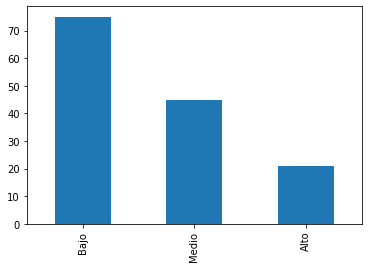

In [16]:
frecuencias_absolutas_altura_penaltis.plot.bar()

In [17]:
frecuencias_relativas_altura_penaltis = frecuencias_absolutas_altura_penaltis.copy()
frecuencias_relativas_altura_penaltis = frecuencias_relativas_altura_penaltis/frecuencias_relativas_altura_penaltis.sum()
frecuencias_relativas_altura_penaltis


Bajo     0.531915
Medio    0.319149
Alto     0.148936
Name: Altura, dtype: float64

In [18]:
frecuencias_relativas_altura_penaltis.sum() == 1

True

<AxesSubplot:ylabel='Altura'>

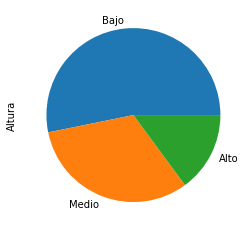

In [19]:
frecuencias_relativas_altura_penaltis.plot.pie()

### Variables Cuantitativas Discretas

In [20]:
portatiles = portatiles.dropna()
portatiles

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [21]:
portatiles['Ram'].unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '6GB', '32GB', '24GB', '64GB'],
      dtype=object)

In [22]:
ram_portatiles = portatiles['Ram']
ram_portatiles

0        8GB
1        8GB
2        8GB
3       16GB
4        8GB
        ... 
1298     4GB
1299    16GB
1300     2GB
1301     6GB
1302     4GB
Name: Ram, Length: 1303, dtype: object

In [23]:
ram_portatiles.value_counts()

8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: Ram, dtype: int64

<AxesSubplot:>

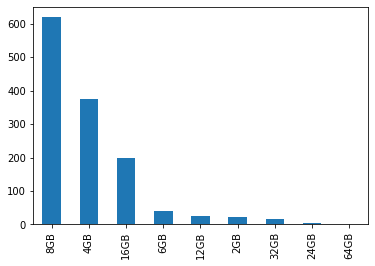

In [24]:
ram_portatiles.value_counts().plot.bar()

In [25]:
#Podemos hacer un "diagrama de barras" con varias observaciones a la vez.
malaga_primeros_dias = malaga.iloc[0:15,:]
malaga_primeros_dias

,DateTime,Scheduled flights,Tracked flights
0,18/02/2022,148,139
1,19/02/2022,147,143
2,20/02/2022,162,153
3,21/02/2022,136,131
4,22/02/2022,99,97
5,23/02/2022,108,106
6,24/02/2022,109,102
7,25/02/2022,155,149
8,26/02/2022,143,141
9,27/02/2022,160,151


<AxesSubplot:xlabel='DateTime'>

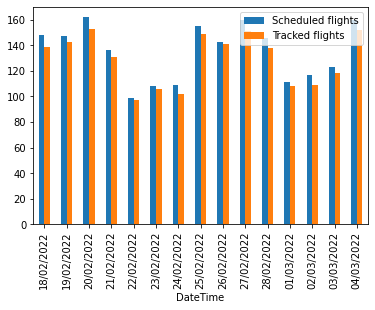

In [26]:
malaga_primeros_dias.plot.bar(x = 'DateTime')

In [27]:
vuelos_primeros_dias = vuelos.iloc[0:15,:]
vuelos_primeros_dias

,DateTime,Scheduled flights,Tracked flights
0,2022-02-18,92,88
1,2022-02-19,82,73
2,2022-02-20,97,92
3,2022-02-21,84,74
4,2022-02-22,68,53
5,2022-02-23,88,74
6,2022-02-24,86,3
7,2022-02-25,93,0
8,2022-02-26,84,0
9,2022-02-27,104,0


<AxesSubplot:xlabel='DateTime'>

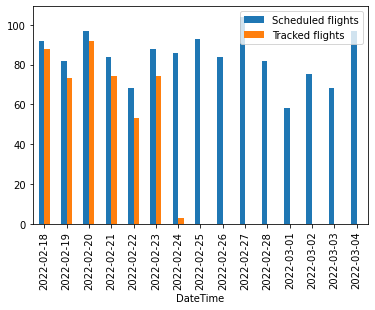

In [28]:
vuelos_primeros_dias.plot.bar(x = 'DateTime')

In [ ]:
#La curva acumulativa habría que hacerla a mano.

### Variables Cuantitativas Continuas

In [29]:
precio_portatiles = portatiles['Price_euros']
precio_portatiles

0       1339.69
1        898.94
2        575.00
3       2537.45
4       1803.60
         ...   
1298     638.00
1299    1499.00
1300     229.00
1301     764.00
1302     369.00
Name: Price_euros, Length: 1303, dtype: float64

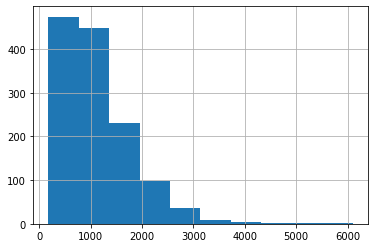

In [30]:
#Histograma
histograma = precio_portatiles.hist()

<AxesSubplot:>

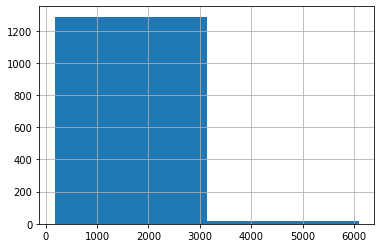

In [31]:
#Cambiar el número de intervalos
precio_portatiles.hist(bins = 2)

array([<AxesSubplot:title={'center':'F'}>,
       <AxesSubplot:title={'center':'M'}>], dtype=object)

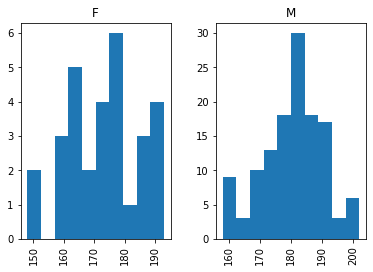

In [32]:
#Podemos hacer diagramas de barras para distintos valores.
jjoo.loc[:,['Sex', 'Height']].hist(by='Sex')

In [ ]:
#No haremos polígono de frecuencias ni curva acumulativa

## Detección de Datos Atípicos (Outliers) 🕵️‍♂️🕵️‍♀️


In [33]:
jjoo

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold
44,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Horse Vault,Gold
48,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Pommelled Horse,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1772,980,"Rebecca ""Becky"" Adlington",F,19.0,179.0,70.0,Great Britain,GBR,2008 Summer,2008,Summer,Beijing,Swimming,Swimming Women's 400 metres Freestyle,Gold
1773,980,"Rebecca ""Becky"" Adlington",F,19.0,179.0,70.0,Great Britain,GBR,2008 Summer,2008,Summer,Beijing,Swimming,Swimming Women's 800 metres Freestyle,Gold
1774,980,"Rebecca ""Becky"" Adlington",F,23.0,179.0,70.0,Great Britain,GBR,2012 Summer,2012,Summer,London,Swimming,Swimming Women's 400 metres Freestyle,Bronze
1775,980,"Rebecca ""Becky"" Adlington",F,23.0,179.0,70.0,Great Britain,GBR,2012 Summer,2012,Summer,London,Swimming,Swimming Women's 800 metres Freestyle,Bronze


<AxesSubplot:>

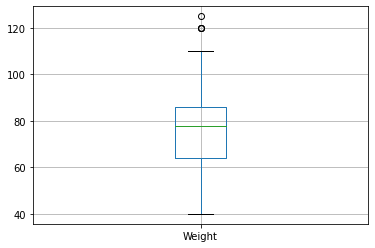

In [34]:
jjoo.boxplot(column = 'Weight')

<AxesSubplot:>

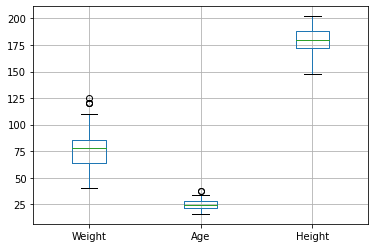

In [35]:
jjoo.boxplot(column = ['Weight', 'Age', 'Height'])

<AxesSubplot:>

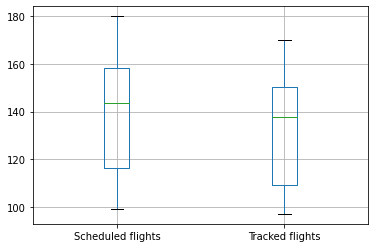

In [36]:
malaga.boxplot()

<AxesSubplot:>

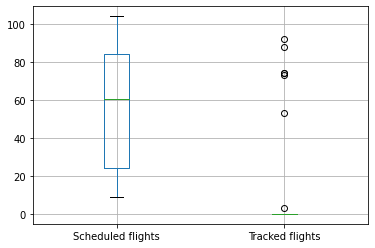

In [37]:
vuelos.boxplot()

<AxesSubplot:>

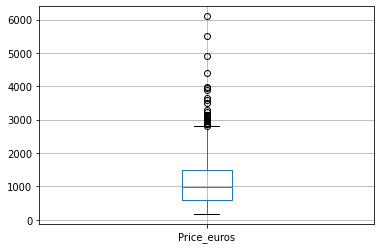

In [38]:
portatiles.boxplot(column = 'Price_euros')

## Medidas de Tendencia Central y Medidas de Posición 🎯

In [39]:
#Media:
portatiles.mean()

<ipython-input-39-ba46f76f6907>:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  portatiles.mean()


laptop_ID       660.155794
Inches           15.017191
Price_euros    1123.686992
dtype: float64

In [ ]:
#Posible ejercicio: comprobar que media(y) = a*media(x)+ b

In [40]:
#Mediana
portatiles.median()

<ipython-input-40-226e8225cd25>:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  portatiles.median()


laptop_ID      659.0
Inches          15.6
Price_euros    977.0
dtype: float64

In [41]:
#Desviación típica
portatiles.std()

<ipython-input-41-e2554d51d8d0>:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  portatiles.std()


laptop_ID      381.172104
Inches           1.426304
Price_euros    699.009043
dtype: float64

In [42]:
#Varianza
(portatiles.std())**2

<ipython-input-42-9aead6f0d2d1>:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  (portatiles.std())**2


laptop_ID      145292.173098
Inches              2.034343
Price_euros    488613.641544
dtype: float64

In [ ]:
#Posible ejercicio: análogo al de la media

In [43]:
#Cuartiles
portatiles.quantile(q = [0.25, 0.5, 0.75])

,laptop_ID,Inches,Price_euros
0.25,331.5,14.0,599.00
0.50,659.0,15.6,977.00
0.75,990.5,15.6,1487.88


In [44]:
#Otros percentiles
portatiles.quantile(q = [0.1,0.43, 0.9, 0.95, 0.99, 0.99999])


,laptop_ID,Inches,Price_euros
0.10000,133.20000,13.300000,393.5720
0.43000,566.86000,15.600000,859.0086
0.90000,1189.80000,17.300000,2040.8000
0.95000,1254.90000,17.300000,2448.6000
0.99000,1306.98000,17.300000,3148.9674
0.99999,1319.98698,18.385678,6091.1880


## Variables Estadísticas Bidimensionales 2️⃣

### Distribuciones Condicionadas

array([<AxesSubplot:title={'center':'F'}>,
       <AxesSubplot:title={'center':'M'}>], dtype=object)

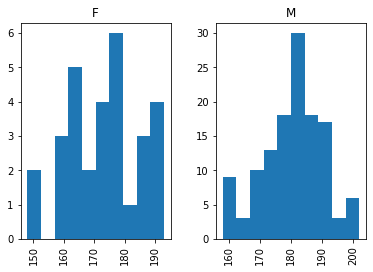

In [45]:
# Repetimos gráfico 
jjoo.loc[:,['Sex', 'Height']].hist(by='Sex')

In [46]:
#Queremos saber la altura media de las mujeres

jjoo_mujeres = jjoo.loc[jjoo['Sex']=='F',:] #Hemos condicionado los datos a las mujeres.
jjoo_mujeres

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
105,37,Ann Kristin Aarnes,F,23.0,182.0,64.0,Norway,NOR,1996 Summer,1996,Summer,Atlanta,Football,Football Women's Football,Bronze
161,65,Patimat Abakarova,F,21.0,165.0,49.0,Azerbaijan,AZE,2016 Summer,2016,Summer,Rio de Janeiro,Taekwondo,Taekwondo Women's Flyweight,Bronze
163,67,Mariya Vasilyevna Abakumova (-Tarabina),F,22.0,179.0,80.0,Russia,RUS,2008 Summer,2008,Summer,Beijing,Athletics,Athletics Women's Javelin Throw,Silver
195,90,Tamila Rashidovna Abasova,F,21.0,163.0,60.0,Russia,RUS,2004 Summer,2004,Summer,Athina,Cycling,Cycling Women's Sprint,Silver
286,153,Monica Cecilia Abbott,F,23.0,191.0,88.0,United States,USA,2008 Summer,2008,Summer,Beijing,Softball,Softball Women's Softball,Silver
311,165,Nia Nicole Abdallah,F,20.0,175.0,56.0,United States,USA,2004 Summer,2004,Summer,Athina,Taekwondo,Taekwondo Women's Featherweight,Silver
476,259,Reema Abdo,F,21.0,173.0,59.0,Canada,CAN,1984 Summer,1984,Summer,Los Angeles,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze
677,394,Irene Abel,F,19.0,160.0,48.0,East Germany,GDR,1972 Summer,1972,Summer,Munich,Gymnastics,Gymnastics Women's Team All-Around,Silver
684,395,Jennifer Abel,F,20.0,160.0,62.0,Canada,CAN,2012 Summer,2012,Summer,London,Diving,Diving Women's Synchronized Springboard,Bronze
747,428,Elvan Abeylegesse,F,25.0,159.0,40.0,Turkey,TUR,2008 Summer,2008,Summer,Beijing,Athletics,"Athletics Women's 5,000 metres",Silver


In [47]:
#Altura media de las mujeres
jjoo_mujeres['Height'].mean()

173.5

In [48]:
#Queremos saber el peso mediano de los participantes entre 20 y 23 años.
jjoo_jovenes = jjoo.loc[(jjoo['Age']>=20)& (jjoo['Age']<=23),:] 
jjoo_jovenes

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
60,20,Kjetil Andr Aamodt,M,20.0,176.0,85.0,Norway,NOR,1992 Winter,1992,Winter,Albertville,Alpine Skiing,Alpine Skiing Men's Super G,Gold
61,20,Kjetil Andr Aamodt,M,20.0,176.0,85.0,Norway,NOR,1992 Winter,1992,Winter,Albertville,Alpine Skiing,Alpine Skiing Men's Giant Slalom,Bronze
63,20,Kjetil Andr Aamodt,M,22.0,176.0,85.0,Norway,NOR,1994 Winter,1994,Winter,Lillehammer,Alpine Skiing,Alpine Skiing Men's Downhill,Silver
64,20,Kjetil Andr Aamodt,M,22.0,176.0,85.0,Norway,NOR,1994 Winter,1994,Winter,Lillehammer,Alpine Skiing,Alpine Skiing Men's Super G,Bronze
67,20,Kjetil Andr Aamodt,M,22.0,176.0,85.0,Norway,NOR,1994 Winter,1994,Winter,Lillehammer,Alpine Skiing,Alpine Skiing Men's Combined,Silver
105,37,Ann Kristin Aarnes,F,23.0,182.0,64.0,Norway,NOR,1996 Summer,1996,Summer,Atlanta,Football,Football Women's Football,Bronze
158,62,Giovanni Abagnale,M,21.0,198.0,90.0,Italy,ITA,2016 Summer,2016,Summer,Rio de Janeiro,Rowing,Rowing Men's Coxless Pairs,Bronze
161,65,Patimat Abakarova,F,21.0,165.0,49.0,Azerbaijan,AZE,2016 Summer,2016,Summer,Rio de Janeiro,Taekwondo,Taekwondo Women's Flyweight,Bronze
163,67,Mariya Vasilyevna Abakumova (-Tarabina),F,22.0,179.0,80.0,Russia,RUS,2008 Summer,2008,Summer,Beijing,Athletics,Athletics Women's Javelin Throw,Silver
173,73,Luc Abalo,M,23.0,182.0,86.0,France,FRA,2008 Summer,2008,Summer,Beijing,Handball,Handball Men's Handball,Gold


In [49]:
#Calculamos el peso mediano
jjoo_jovenes['Weight'].median()

78.0

### Representaciones Gráficas

In [50]:
#Dibujamos una nube de puntos de las variables peso y altura.
peso_jjoo = jjoo['Weight']
altura_jjoo = jjoo['Height']

In [51]:
peso_jjoo

40       85.0
41       64.0
42       64.0
44       64.0
48       64.0
        ...  
1772     70.0
1773     70.0
1774     70.0
1775     70.0
1807    100.0
Name: Weight, Length: 157, dtype: float64

In [52]:
altura_jjoo

40      184.0
41      175.0
42      175.0
44      175.0
48      175.0
        ...  
1772    179.0
1773    179.0
1774    179.0
1775    179.0
1807    202.0
Name: Height, Length: 157, dtype: float64

Text(0, 0.5, 'Peso')

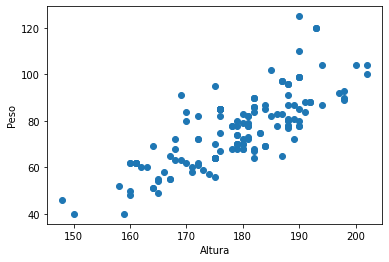

In [53]:
plt.scatter(altura_jjoo, peso_jjoo)
plt.xlabel('Altura')
plt.ylabel('Peso')

###Medidas que relacionan ambas variables

In [54]:
#Las medias y varianzas marginales ya hemos visto como se calculan.
#Veamos como calcular la varianza.
covarianza_altura_peso = altura_jjoo.cov(peso_jjoo)
covarianza_altura_peso

131.03642005552842

In [55]:
#Vamos a calcular las varianzas marginales:
varianza_altura = altura_jjoo.std()**2
varianza_altura


112.87301976155481

In [56]:
varianza_peso = peso_jjoo.std()**2
varianza_peso

251.9435734117263

### Regresión 📈📉

In [87]:
#Modelo de regresión de Y sobre X
modelo_y_sobre_x = linear_model.LinearRegression()
N_jjoo = len(altura_jjoo) #157
modelo_regresion_y_sobre_x = modelo_y_sobre_x.fit(np.array(altura_jjoo).reshape((N_jjoo, 1)),np.array(peso_jjoo).reshape((N_jjoo, 1)))
a_y_sobre_x = modelo_regresion_y_sobre_x.coef_[0][0]
b_y_sobre_x = modelo_regresion_y_sobre_x.intercept_[0]


In [58]:
a_y_sobre_x

1.1609188832933137

In [59]:
b_y_sobre_x

-131.18269218943408

In [60]:
#Observamos que a_y_sobre_x = cov/varianza peso
covarianza_altura_peso/varianza_altura

1.1609188832933144

In [61]:
#Podemos hacer predicciones
modelo_regresion_y_sobre_x.predict(np.array([162]).reshape(1,1))

array([[56.8861669]])

In [63]:
#Dibujamos los puntos y la recta de regresión de y sobre x
x_altura = np.linspace(start = 150, stop = 200, num = 1000)
y_peso = a_y_sobre_x* x_altura + b_y_sobre_x

In [64]:
x_altura[0:10]

array([150.        , 150.05005005, 150.1001001 , 150.15015015,
       150.2002002 , 150.25025025, 150.3003003 , 150.35035035,
       150.4004004 , 150.45045045])

In [65]:
y_peso[0:10]

array([42.9551403 , 43.01324435, 43.0713484 , 43.12945245, 43.1875565 ,
       43.24566055, 43.30376459, 43.36186864, 43.41997269, 43.47807674])

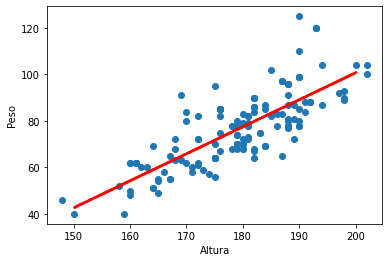

In [66]:
plt.scatter(altura_jjoo, peso_jjoo)
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.scatter(x_altura, y_peso, c ='red', s = 1)

In [94]:
#También podemos calcular la recta de regresión de X sobre Y
modelo_x_sobre_y = linear_model.LinearRegression()
N_jjoo = len(altura_jjoo) #157
modelo_regresion_x_sobre_y = modelo_x_sobre_y.fit(np.array(peso_jjoo).reshape((N_jjoo, 1)),np.array(altura_jjoo).reshape((N_jjoo, 1)))
a_x_sobre_y = modelo_regresion_x_sobre_y.coef_[0][0]
b_x_sobre_y = modelo_regresion_x_sobre_y.intercept_[0]


In [95]:
a_x_sobre_y

0.5201022525841077

In [96]:
b_x_sobre_y

139.20183087484818

In [97]:
varianza_peso/covarianza_altura_peso

1.9226988443744255

In [98]:
covarianza_altura_peso/varianza_peso

0.520102252584108

In [ ]:
# Notar que 1.92>1.16 (como dice el teorema)

In [99]:
# Ahora vamos a dibujar ambas rectas de regresión
x_altura = np.linspace(start = 150, stop = 200, num = 1000)
y_peso = a_y_sobre_x* x_altura + b_y_sobre_x

x_peso = np.linspace(start = 40, stop = 120, num = 5000)
y_altura = a_x_sobre_y* x_peso + b_x_sobre_y


In [100]:
x_peso[0:10]

array([40.        , 40.0160032 , 40.0320064 , 40.0480096 , 40.0640128 ,
       40.080016  , 40.0960192 , 40.1120224 , 40.12802561, 40.14402881])

In [101]:
y_altura[0:10]

array([160.00592098, 160.01424428, 160.02256758, 160.03089088,
       160.03921418, 160.04753748, 160.05586078, 160.06418408,
       160.07250738, 160.08083068])

In [102]:
# Hacemos predicciones de la recta de X sobre Y
modelo_regresion_x_sobre_y.predict(np.array([94]).reshape(1,1))

array([[188.09144262]])

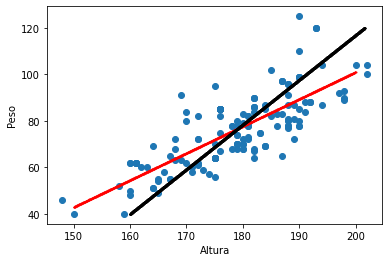

In [103]:
plt.scatter(altura_jjoo, peso_jjoo)
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.scatter(x_altura, y_peso, c ='red', s = 1)
plt.scatter(y_altura, x_peso, c ='black', s = 1)

In [104]:
#Veamos el centro de gravedad
altura_jjoo.mean()

179.13375796178343

In [105]:
peso_jjoo.mean()

76.77707006369427

### Coeficientes de Correlación $\rho$ y Determinación $R^2$

In [106]:
# Coeficiente de Correlación
coeficiente_de_correlacion = altura_jjoo.corr(peso_jjoo)
coeficiente_de_correlacion

0.7770434519821141

In [107]:
#Coeficiente de Determinación

coeficiente_de_determinacion = coeficiente_de_correlacion**2
coeficiente_de_determinacion

0.6037965262682801

In [108]:
#Cuidado R^2 no coincide con la función .score()
modelo_regresion_y_sobre_x.score(X = np.array(peso_jjoo).reshape((N_jjoo, 1)),y = np.array(altura_jjoo).reshape((N_jjoo, 1)))

-436.52146977890845

In [109]:
# Matrix de correlaciones (heatmap)
jjoo_tres_variables = jjoo[['Age', 'Height', 'Weight']]
jjoo_tres_variables

,Age,Height,Weight
40,28.0,184.0,85.0
41,28.0,175.0,64.0
42,28.0,175.0,64.0
44,28.0,175.0,64.0
48,28.0,175.0,64.0
...,...,...,...
1772,19.0,179.0,70.0
1773,19.0,179.0,70.0
1774,23.0,179.0,70.0
1775,23.0,179.0,70.0


In [110]:
jjoo_tres_variables.corr().style.background_gradient(cmap='coolwarm')

,Age,Height,Weight
Age,1.000000,0.136393,0.218095
Height,0.136393,1.000000,0.777043
Weight,0.218095,0.777043,1.000000


In [111]:
edad_jjoo = jjoo['Age']
edad_jjoo

40      28.0
41      28.0
42      28.0
44      28.0
48      28.0
        ... 
1772    19.0
1773    19.0
1774    23.0
1775    23.0
1807    26.0
Name: Age, Length: 157, dtype: float64

Text(0, 0.5, 'Altura')

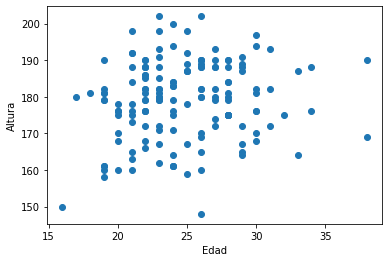

In [112]:
plt.scatter(edad_jjoo, altura_jjoo)
plt.xlabel ('Edad')
plt.ylabel('Altura')

Text(0, 0.5, 'Peso')

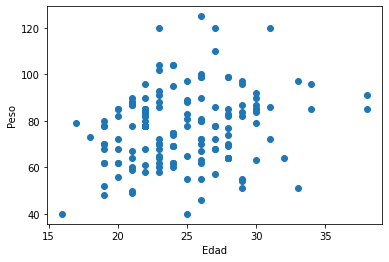

In [113]:
plt.scatter(edad_jjoo, peso_jjoo)
plt.xlabel ('Edad')
plt.ylabel('Peso')

# Antes de irte 🏃‍♀️🏃‍♂️

* No olvides descargar tu archivo (Archivo --> Descargar --> Descargar .ipynb)
* Si se te olvida guardarlo, recuerda que puedes encontrarlo en tu Google Drive 🙃